# Vectorised Simulations & Broadcasting

One of Cheetah's most powerful features is its native support for vectorised simulations and broadcasting, inherited directly from PyTorch. This allows you to simulate multiple beam configurations and magnet settings in parallel, fully avoiding slow Python-level loops.

Vectorised simulations are ideal for tasks like **sensitivity analysis, parameter sweeps, reinforcement learning ensemble training, and Bayesian optimisation**.

## Vectorising Beams

Both beam classes in Cheetah support vectorisation dimensions. By providing multi-dimensional tensors to the beam constructors, you can define a vectorised set of different beam distributions:

### ParameterBeam
For `ParameterBeam`, the shapes are:
- `mu`: `(..., 7)` where `...` represents any number of vectorisation dimensions.
- `cov`: `(..., 7, 7)`

For example, a vectorised set of 100 parameter beams is represented by `mu` of shape `(100, 7)` and `cov` of shape `(100, 7, 7)`.

### ParticleBeam
For `ParticleBeam`, the shapes are:
- `particles`: `(..., N, 7)` where `N` is the number of macroparticles and `...` are the vectorisation dimensions.

For example, a vectorised set of 100 particle beams, each containing 10,000 particles, is represented by a tensor of shape `(100, 10000, 7)`.

## Vectorising Elements

Lattice element parameters (like a quadrupole's `k1` or a drift's `length`) can also be multi-dimensional PyTorch tensors.

In [1]:
import torch
import cheetah

# Define 50 different strength settings for a quadrupole magnet
k1_settings = torch.linspace(-15.0, 15.0, 50)

# Create a quadrupole element with vectorised settings
quadrupole = cheetah.Quadrupole(length=torch.tensor(0.122), k1=k1_settings)
print("quadrupole k1 shape:", quadrupole.k1.shape)

quadrupole k1 shape: torch.Size([50])


During tracking, Cheetah computes the transfer map for all 50 quadrupole settings in parallel.

---

## PyTorch Broadcasting in Action

When a beam is tracked through an element, PyTorch's native broadcasting rules are applied:
- If a vectorised beam with shape `(B, ...)` is tracked through a vectorised element with setting shape `(M, ...)`, the shapes will broadcast.
- The output beam will have vectorised dimensions `(B, M)`.

This enables parallel parameter sweeps over various beam conditions and magnet settings simultaneously.

### Example: Quadrupole Setting Sweep

The following example demonstrates how to perform a parameter sweep of a quadrupole's strength (`k1`) and measure its impact on the beam's horizontal envelope size ($\sigma_x$), completely in parallel.

Outgoing mu shape: torch.Size([100, 7])
Outgoing cov shape: torch.Size([100, 7, 7])


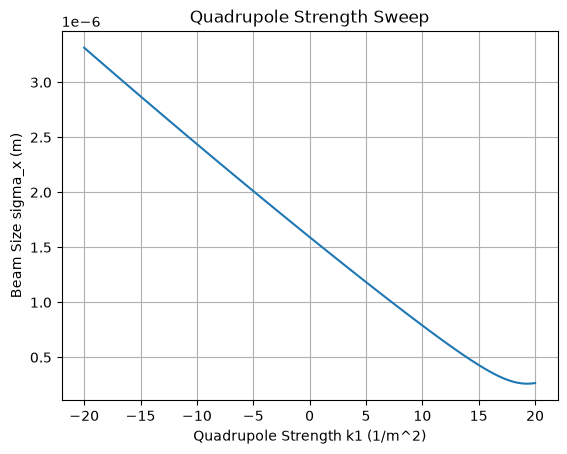

In [2]:
import torch
import cheetah
import matplotlib.pyplot as plt

# 1. Define a simple lattice with a vectorised quadrupole
k1_sweep = torch.linspace(-20.0, 20.0, 100)
segment = cheetah.Segment(
    elements=[
        cheetah.Drift(length=torch.tensor(0.5)),
        cheetah.Quadrupole(length=torch.tensor(0.1), k1=k1_sweep, name="QD"),
        cheetah.Drift(length=torch.tensor(0.5)),
    ]
)

# 2. Create an incoming beam (single beam)
incoming = cheetah.ParameterBeam.from_twiss(
    beta_x=torch.tensor(3.14),
    beta_y=torch.tensor(3.14),
    energy=torch.tensor(1e7)
)

# 3. Track the beam (broadcasts over the 100 quadrupole settings)
outgoing = segment.track(incoming)

# The outgoing beam now contains 100 beam parameter sets
print("Outgoing mu shape:", outgoing.mu.shape)   # torch.Size([100, 7])
print("Outgoing cov shape:", outgoing.cov.shape)  # torch.Size([100, 7, 7])

# 4. Extract sigma_x and plot the results
sigma_x = torch.sqrt(outgoing.cov[..., 0, 0])

plt.figure()
plt.plot(k1_sweep.numpy(), sigma_x.numpy())
plt.xlabel("Quadrupole Strength k1 (1/m^2)")
plt.ylabel("Beam Size sigma_x (m)")
plt.title("Quadrupole Strength Sweep")
plt.grid(True)
plt.show()